# Bank customer churn analysis

This notebook will include an exploration of the [Bank Customer Churn dataset](https://mavenanalytics.io/data-playground/bank-customer-churn) by [Maven Analytics](https://mavenanalytics.io/). We will start from the raw dataset (`Bank_Churn_Messy.xlsx`).

The analysis will include data cleaning, exploring how current and churned accounts differ, highlight potential causes to customer churn and explore clustering methods for customer segmentation.

## Table of contents
1. [Import and clean data](#Import-and-clean-data)
2. [Understanding the data](#Understanding-the-data)
3. [Customer distributions](#Customer-distributions)
4. [Scalable methods for measuring variable relationships](#Scalable-methods-for-measuring-variable-relationships)
5. [Customer segmentation (clustering)](#Customer-segmentation-(clustering))
6. [Conclusions](#Conclusions)

In [1]:
import polars as pl

from quoi.stats import (
    get_top,
    summary,
    normalize
)

from quoi.viz import (
    add_titles,
    plot_line,
    plot_bar,
    setup_chart_template
)

from quoi.clustering import hopkins_statistic, scree_plot

from datetime import timedelta
from itertools import combinations
import numpy as np
import polars as pl
import plotly.express as px
import plotly.graph_objects as go

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import SpectralClustering

import xgboost as xgb

import os
from dotenv import load_dotenv
from IPython.display import Image, display

load_dotenv()
setup_chart_template(from_notebook=True)

# Set to True so the .ipynb has a chart preview when archived
RENDER_AS_PNG = True

def display_as_png(fig, w=1200, h=700):
    display(Image(fig.to_image(format='png', width=w, height=h)))

## Import and clean data

There isn't much preprocessing needed, as there are very few missing values and there doesn't seem to be duplicated data.

In [2]:
# Since there isn't much preprocessing, both import and preprocessing are in the same cell 
# to self contain and prevent cell re-run problems
DATA_FILEPATH = os.getenv('DATA_FILEPATH')

if not DATA_FILEPATH:
    raise EnvironmentError("Please set 'DATA_FILEPATH' variable in .env to proceed.")

FILENAME = 'Bank_Churn_Messy.xlsx'
df_customer, df_account = pl.read_excel(os.path.join(DATA_FILEPATH, FILENAME), sheet_id=0).values()


# Preprocessing and changes to data out of preference

# Rename columns to snake_case
df_customer = df_customer.rename({col: ''.join([f'_{el.lower()}' if el.isupper() else el for el in col]).lstrip('_') \
                                  for col in df_customer.columns})
df_account = df_account.rename({col: ''.join([f'_{el.lower()}' if el.isupper() else el for el in col]).lstrip('_') \
                                for col in df_account.columns})

# Confirm all currency related columns are in Euros
assert df_customer.filter(~pl.col('estimated_salary').str.contains('€')).is_empty()
assert df_account.filter(~pl.col('balance').str.contains('€')).is_empty()

# Column-level corrections
df_customer = df_customer.with_columns(
    # Change "FRA" (France alpha-3 code) and "French" to "France" for consistency
    pl.col('geography').replace('French', 'France').replace('FRA', 'France'),
    
    # All estimated salaries are in Euros, so we cast these to float and make the currency explicit on the column name
    pl.col('estimated_salary').str.replace('€', '').cast(pl.Float64)
).rename({'estimated_salary': 'estimated_salary_eur'})

df_account = df_account.with_columns(
    # Same thing as estimated_salary above
    pl.col('balance').str.replace('€', '').cast(pl.Float64),

    # Cast every no/yes or 0/1 column as bool for consistency
    (pl.col('has_cr_card') == 'Yes'),
    (pl.col('is_active_member') == 'Yes'),
    (pl.col('exited') == 1)
).rename({'balance': 'balance_eur'})

In [3]:
print('Column summary for customer dataframe:')
summary(df_customer)

Column summary for customer dataframe:


column,dtype,nunique,missing,share_missing
str,object,i64,i64,f64
"""customer_id""",Int64,10000,0,0.0
"""surname""",String,2933,3,0.029997
"""credit_score""",Int64,460,0,0.0
"""geography""",String,3,0,0.0
"""gender""",String,2,0,0.0
"""age""",Int64,71,3,0.029997
"""tenure""",Int64,11,0,0.0
"""estimated_salary_eur""",Float64,9997,0,0.0


In [4]:
print('Column summary for account dataframe:')
summary(df_account)

Column summary for account dataframe:


column,dtype,nunique,missing,share_missing
str,object,i64,i64,f64
"""customer_id""",Int64,10000,0,0.0
"""balance_eur""",Float64,6382,0,0.0
"""num_of_products""",Int64,4,0,0.0
"""has_cr_card""",Boolean,2,0,0.0
"""tenure""",Int64,11,0,0.0
"""is_active_member""",Boolean,2,0,0.0
"""exited""",Boolean,2,0,0.0


## Understanding the data

There are two provided tables:
 - Customer info: surname, credit score, country, gender, age, tenure and estimated salary (in euros);
 - Account info: account balance, total used products, whether or not they have a credit card, tenure (in years), whether or not the member is active and if the user left.

Some questions arise:
 - What is the margin of error for the estimated salaries?
 - What is the criteria for whether a member is active or not? (Usage recency or usage frequency?)
 - What is the total possible number of bank products?
 - What credit score model should we assume? (FICO, VantageScore, ...?)
 - What is the relationship between being an active member and leaving? We see customers that have both churned and are registered as active members. (Recent activity prior to leaving? If so, this could be used to highlight _some_ recent customer exits)
 - What caused the 3 customers with missing information? (Missing surname, age and estimated salary is -999,999€)

<span style='color: gray'>This last question would require the input of the team that generated the dataset. Since we cannot answer this from our side (especially because all these customers are still members), we don't know how these entries should be handled, so we will drop them.</span>

In [5]:
FLT_MISSING = pl.col('surname').is_null()
IDS_MISSING = sorted(df_customer.filter(FLT_MISSING)['customer_id'].to_list())

df_account.filter(pl.col('customer_id').is_in(IDS_MISSING))

customer_id,balance_eur,num_of_products,has_cr_card,tenure,is_active_member,exited
i64,f64,i64,bool,i64,bool,bool
15728693,141349.43,1,true,3,true,false
15580203,120193.42,1,false,6,false,false
15756954,0.0,1,true,2,true,false


In [6]:
# We will proceed with a merged dataframe going forward
df = df_customer.join(df_account, on='customer_id',
                      how='full', coalesce=True) \
                .filter(~FLT_MISSING) \
                .drop('tenure_right')

Let's check how customers are distributed.

## Customer distributions

There are only three countries in the dataset, France making up roughly half of all customers. Having said that, the majority of customers which have churned live in Germany, despite the client base being around half of France's:

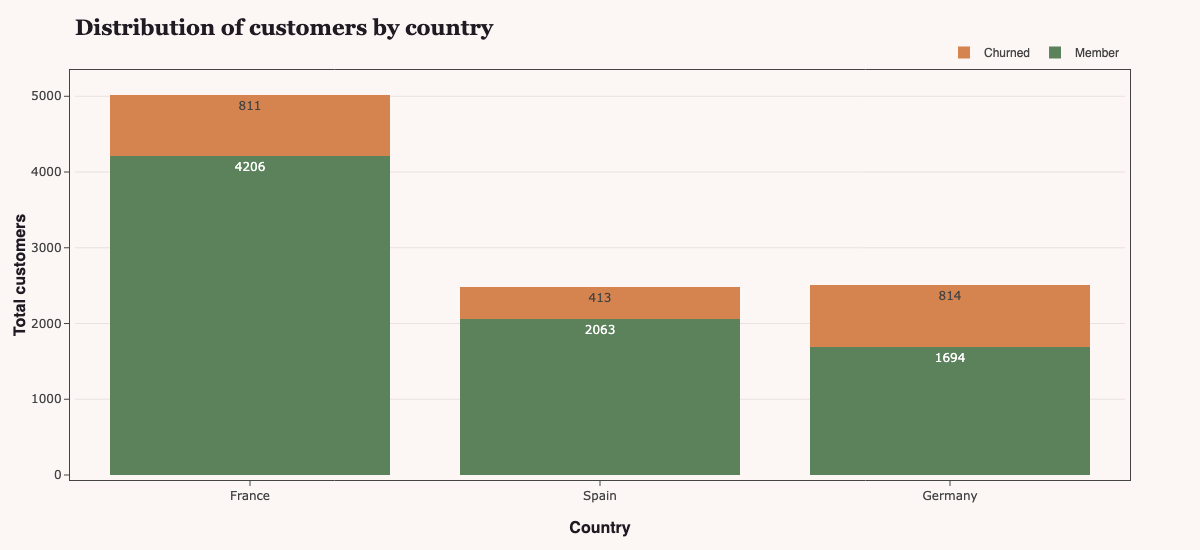

In [7]:
_curr_top = get_top(df, entry_c=['geography', 'exited'], value_c='customer_id', method=pl.Expr.count)

fig = plot_bar(_curr_top, x='geography', y='customer_id', text='customer_id',
               breakdown='exited', breakdown_stack=True,
               title='Distribution of customers by country',
               x_title='Country',
               y_title='Total customers',
               legend_replace={True: 'Churned', False: 'Member'},
               hovertemplate='<br>'.join([
                   '%{x}',
                   '<b>%{yaxis.title.text}:</b> %{y}',
                   '<b>Share of all:</b> %{customdata:.2f}%',
                   '<extra></extra>'
               ]),
               return_fig=True)

fig.update_traces(customdata=_curr_top['share'])

if RENDER_AS_PNG:
    display_as_png(fig, h=550)
else:
    fig.show()

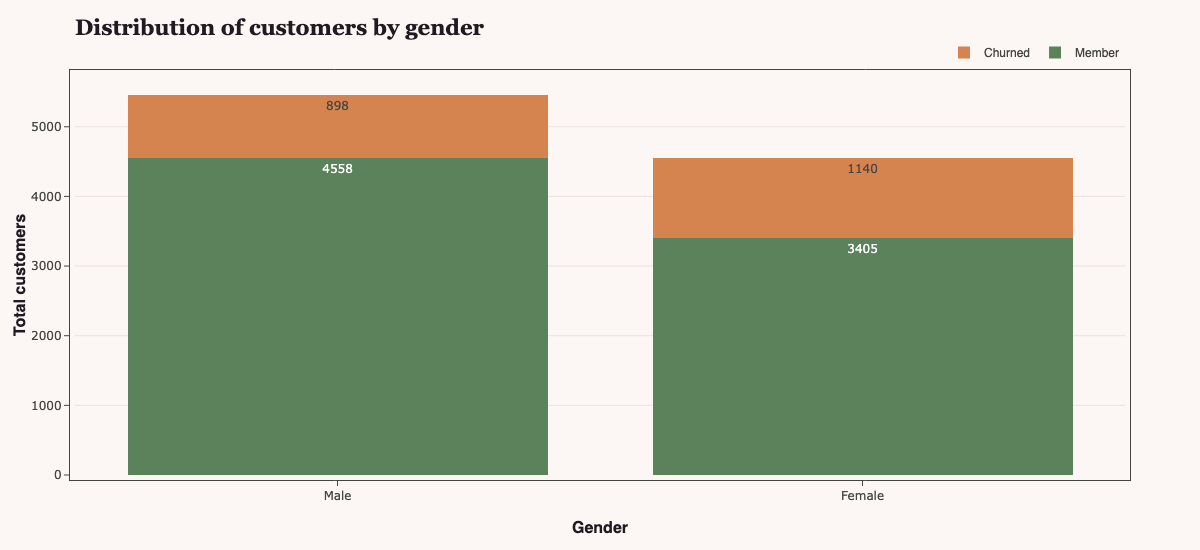

In [8]:
_curr_top = get_top(df, entry_c=['gender', 'exited'], value_c='customer_id', method=pl.Expr.count)

fig = plot_bar(_curr_top, x='gender', y='customer_id', text='customer_id',
               breakdown='exited', breakdown_stack=True,
               title='Distribution of customers by gender',
               x_title='Gender',
               y_title='Total customers',
               legend_replace={True: 'Churned', False: 'Member'},
               hovertemplate='<br>'.join([
                   '%{x}',
                   '<b>%{yaxis.title.text}:</b> %{y}',
                   '<b>Share of all:</b> %{customdata:.2f}%',
                   '<extra></extra>'
               ]),
               return_fig=True)

fig.update_traces(customdata=_curr_top['share'])

if RENDER_AS_PNG:
    display_as_png(fig, h=550)
else:
    fig.show()

Tenure is more or less evenly distributed, except for the extremes of the distribution:

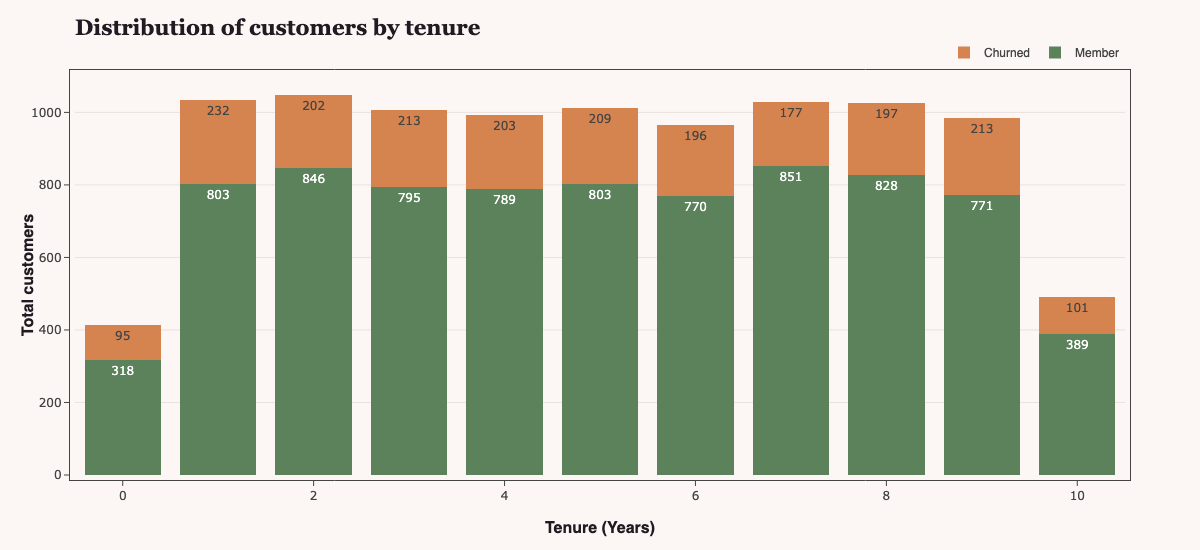

In [9]:
_curr_top = get_top(df, entry_c=['tenure', 'exited'], value_c='customer_id', method=pl.Expr.count).sort('tenure')

fig = plot_bar(_curr_top, x='tenure', y='customer_id', text='customer_id',
               breakdown='exited', breakdown_stack=True,
               title='Distribution of customers by tenure',
               x_title='Tenure (Years)',
               y_title='Total customers',
               legend_replace={True: 'Churned', False: 'Member'},
               hovertemplate='<br>'.join([
                   '<b>%{xaxis.title.text}</b>: %{x}',
                   '<b>%{yaxis.title.text}:</b> %{y}',
                   '<b>Share of all:</b> %{customdata:.2f}%',
                   '<extra></extra>'
               ]),
               return_fig=True)

fig.update_traces(customdata=_curr_top['share'])

if RENDER_AS_PNG:
    display_as_png(fig, h=550)
else:
    fig.show()

Most customers have no more than 2 bank products, but the few ones that do, more likely than not, end up leaving. Customers that register only one product also have a considerable churn rate.

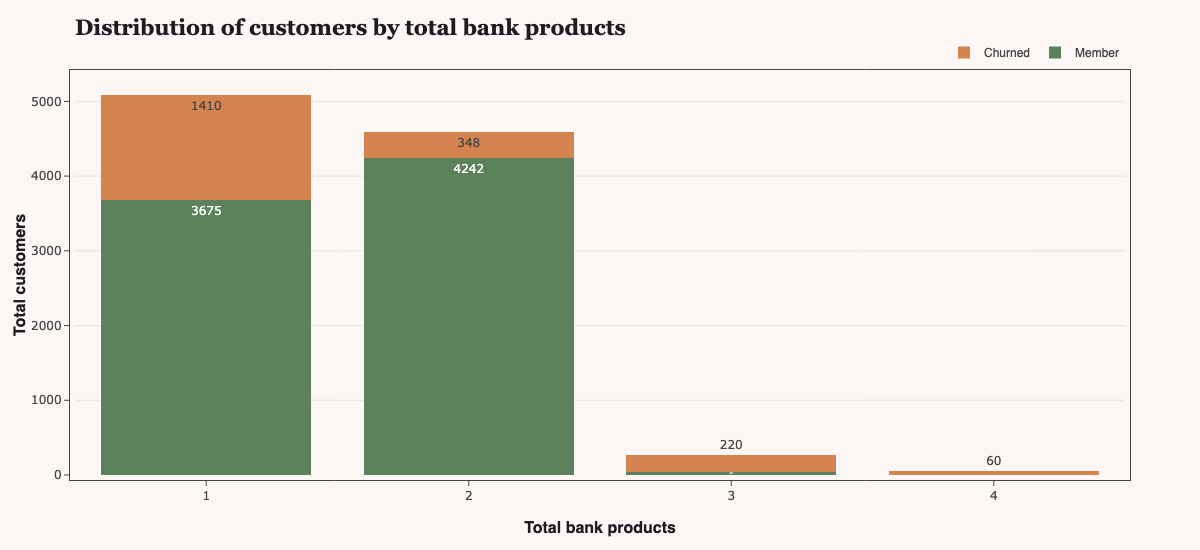

In [10]:
_curr_top = get_top(df, entry_c=['num_of_products', 'exited'], value_c='customer_id', method=pl.Expr.count)

fig = plot_bar(_curr_top, x='num_of_products', y='customer_id', text='customer_id',
               breakdown='exited', breakdown_stack=True,
               title='Distribution of customers by total bank products',
               x_title='Total bank products',
               y_title='Total customers',
               legend_replace={True: 'Churned', False: 'Member'},
               hovertemplate='<br>'.join([
                   '<b>%{xaxis.title.text}</b>: %{x}',
                   '<b>%{yaxis.title.text}:</b> %{y}',
                   '<b>Share of all:</b> %{customdata:.2f}%',
                   '<extra></extra>'
               ]),
               return_fig=True)

fig.update_traces(customdata=_curr_top['share'])

if RENDER_AS_PNG:
    display_as_png(fig, h=550)
else:
    fig.show()

Most customers have a credit card, but the one's that don't tend to leave more.

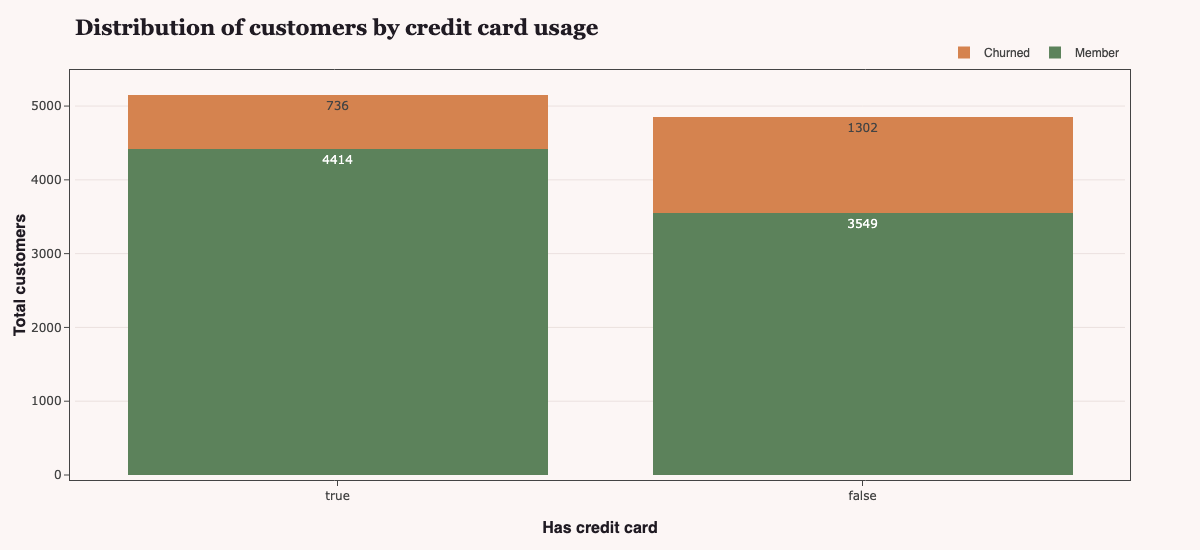

In [11]:
_curr_top = get_top(df, entry_c=['has_cr_card', 'exited'], value_c='customer_id', method=pl.Expr.count)

fig = plot_bar(_curr_top, x='has_cr_card', y='customer_id', text='customer_id',
               breakdown='exited', breakdown_stack=True,
               title='Distribution of customers by credit card usage',
               x_title='Has credit card',
               y_title='Total customers',
               legend_replace={True: 'Churned', False: 'Member'},
               hovertemplate='<br>'.join([
                   '<b>%{xaxis.title.text}</b>: %{x}',
                   '<b>%{yaxis.title.text}:</b> %{y}',
                   '<b>Share of all:</b> %{customdata:.2f}%',
                   '<extra></extra>'
               ]),
               return_fig=True)

fig.update_traces(customdata=_curr_top['share'])

if RENDER_AS_PNG:
    display_as_png(fig, h=550)
else:
    fig.show()

Age is quite the differentiator. Current members tend to be younger, with most having between 30 to 40 years of age. More than half of former customers have between 40 and 55 years of age.

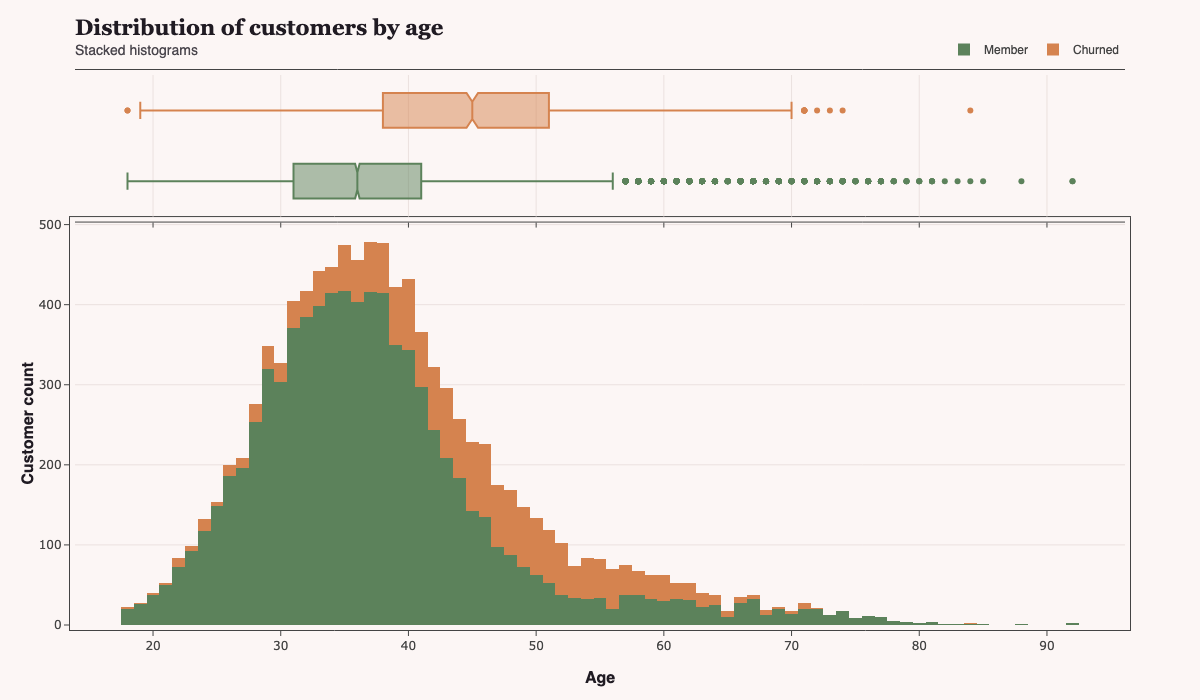

In [12]:
# Sorting so traces are in the order we want
fig = px.histogram(df.sort('exited'),
                   x='age', color='exited', marginal='box', nbins=100)

add_titles(fig,
           title='Distribution of customers by age',
           subtitle='Stacked histograms',
           x_title='Age',
           y_title='Customer count')

fig.update_layout(barmode='stack', height=700)

_legend_replace={'True': 'Churned', 'False': 'Member'}
for i in range(len(fig.data)):
    fig.data[i].name = _legend_replace.get(fig.data[i].name, fig.data[i].name)
    fig.data[i].legendgroup = _legend_replace.get(fig.data[i].legendgroup, fig.data[i].legendgroup)

if RENDER_AS_PNG:
    display_as_png(fig)
else:
    fig.show()

Regarding credit score, while the ranges themselves differ from the underlying score model, the general rule is higher = better. For the data at hand, the highest registered score is 850, which is the expected upper bound for both FICO and VantageScore models. A surprising amount of customers register scores this high, regardless of account status. Quartiles are somewhat similar between members and churned customers, with credit scores being higher overall for members:

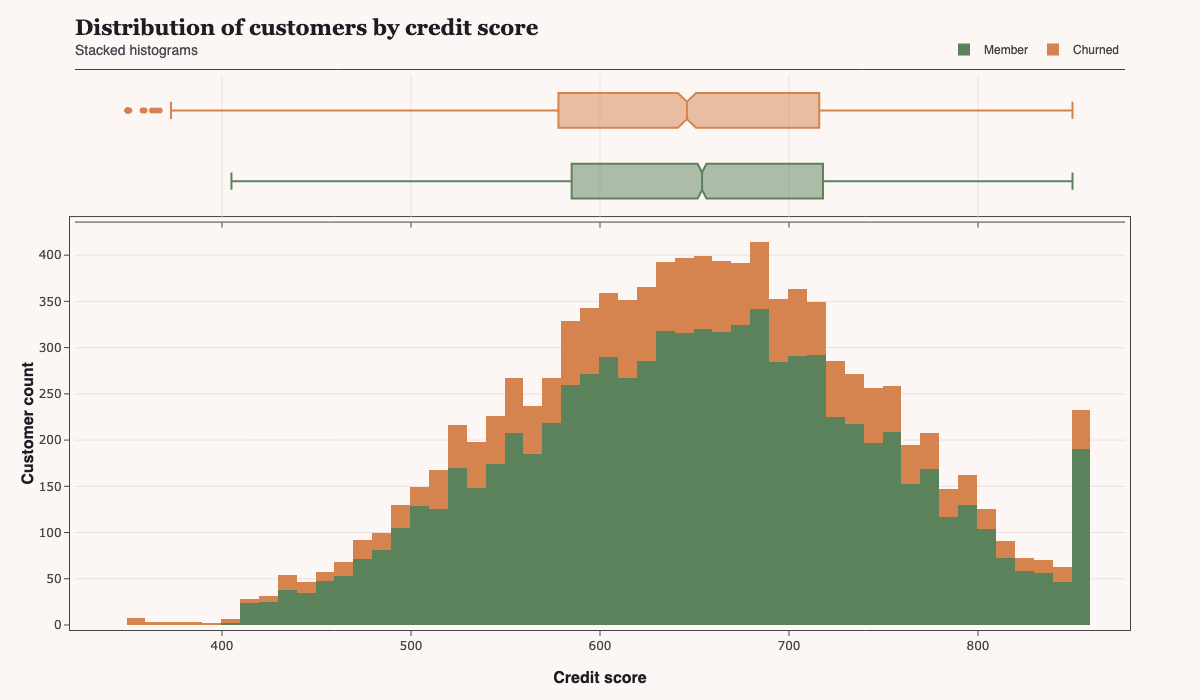

In [13]:
# Sorting so traces are in the order we want
fig = px.histogram(df.sort('exited'),
                   x='credit_score', color='exited', marginal='box', nbins=100)

add_titles(fig,
           title='Distribution of customers by credit score',
           subtitle='Stacked histograms',
           x_title='Credit score',
           y_title='Customer count')

fig.update_layout(barmode='stack', height=700)

_legend_replace={'True': 'Churned', 'False': 'Member'}
for i in range(len(fig.data)):
    fig.data[i].name = _legend_replace.get(fig.data[i].name, fig.data[i].name)
    fig.data[i].legendgroup = _legend_replace.get(fig.data[i].legendgroup, fig.data[i].legendgroup)

if RENDER_AS_PNG:
    display_as_png(fig)
else:
    fig.show()

A considerable share of all registered customers (regardless of account status), have a balance less than 3000€. Disregarding this, account balance follows a normal distribution, with the bulk registering amounts between 100 and 150k euros:

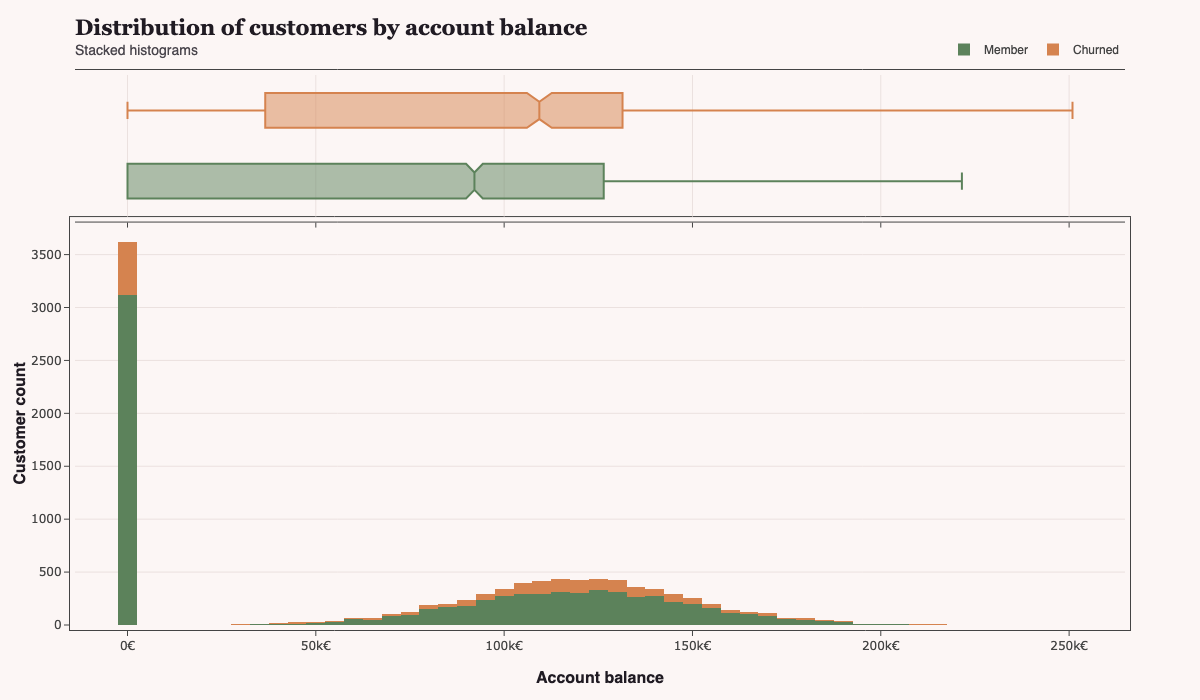

In [14]:
# Sorting so traces are in the order we want
fig = px.histogram(df.sort('exited'),
                   x='balance_eur', color='exited', marginal='box', nbins=100)

add_titles(fig,
           title='Distribution of customers by account balance',
           subtitle='Stacked histograms',
           x_title='Account balance',
           y_title='Customer count')

_legend_replace={'True': 'Churned', 'False': 'Member'}
for i in range(len(fig.data)):
    fig.data[i].name = _legend_replace.get(fig.data[i].name, fig.data[i].name)
    fig.data[i].legendgroup = _legend_replace.get(fig.data[i].legendgroup, fig.data[i].legendgroup)

fig.update_layout(barmode='stack', height=700,
                  xaxis_ticksuffix='€')

if RENDER_AS_PNG:
    display_as_png(fig)
else:
    fig.show()

Let's take a closer look at accounts with low balance (10k€ or less), disregarding account status. Is this related to age?

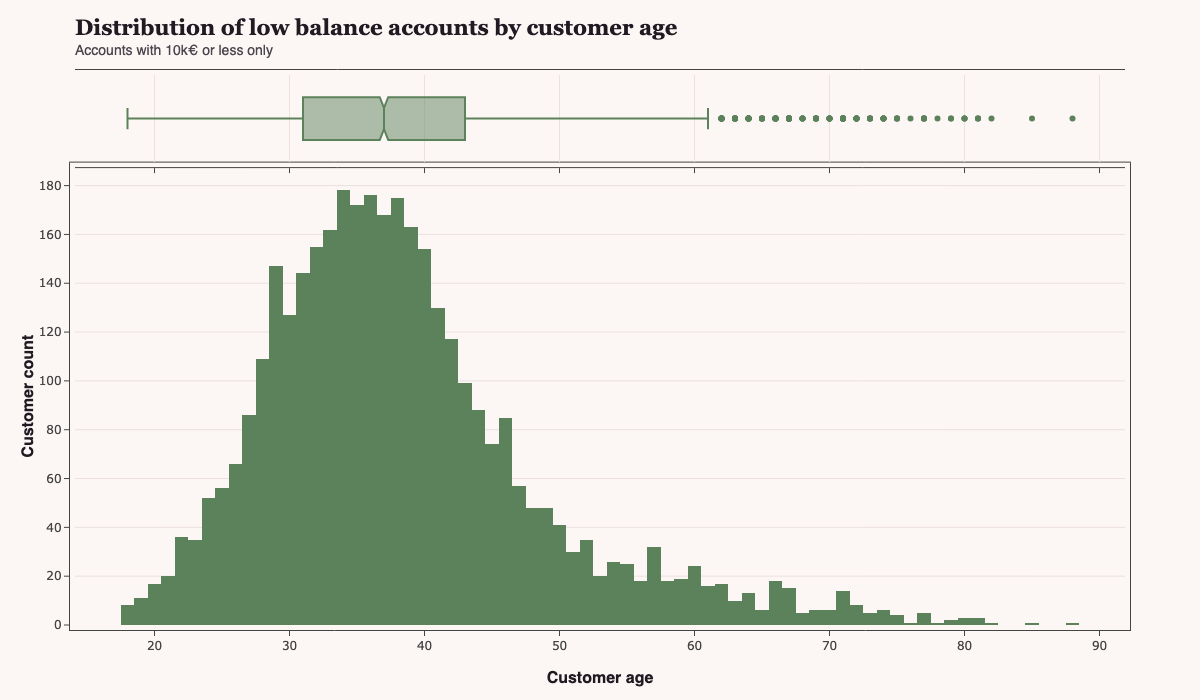

In [15]:
# Sorting so traces are in the order we want
fig = px.histogram(df.filter(pl.col('balance_eur') <= 10000),
                   x='age', marginal='box', nbins=100)

add_titles(fig,
           title='Distribution of low balance accounts by customer age',
           subtitle='Accounts with 10k€ or less only',
           x_title='Customer age',
           y_title='Customer count')

fig.update_layout(height=700)

if RENDER_AS_PNG:
    display_as_png(fig)
else:
    fig.show()

Distribution is pretty close to the overall customer age distribution, so age does not seem to be a factor at all.

Finally, estimated customer salaries seem to be pretty evenly distributed and don't seem to have any bearing whatsoever:

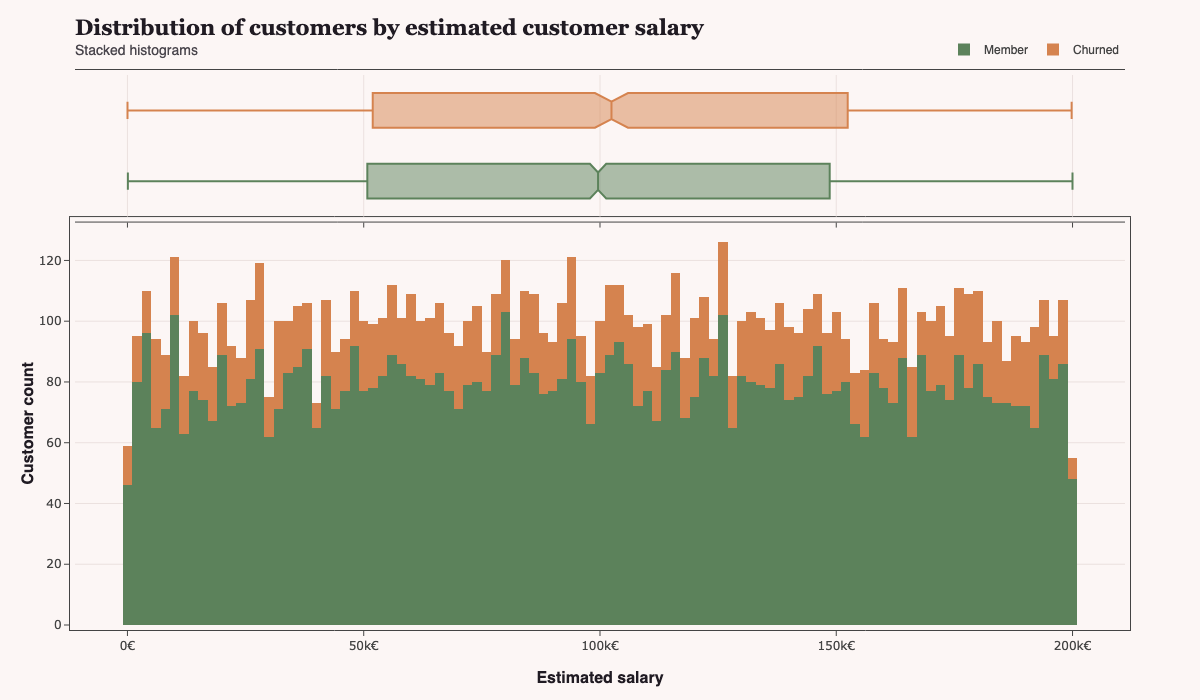

In [16]:
# Sorting so traces are in the order we want
fig = px.histogram(df.sort('exited'),
                   x='estimated_salary_eur', color='exited', marginal='box', nbins=100)

add_titles(fig,
           title='Distribution of customers by estimated customer salary',
           subtitle='Stacked histograms',
           x_title='Estimated salary',
           y_title='Customer count')

_legend_replace={'True': 'Churned', 'False': 'Member'}
for i in range(len(fig.data)):
    fig.data[i].name = _legend_replace.get(fig.data[i].name, fig.data[i].name)
    fig.data[i].legendgroup = _legend_replace.get(fig.data[i].legendgroup, fig.data[i].legendgroup)

fig.update_layout(barmode='stack', height=700,
                  xaxis_ticksuffix='€')

if RENDER_AS_PNG:
    display_as_png(fig)
else:
    fig.show()

This was an extensive look at how most variables relate to account status. We could afford to do this manually because the amount of variables was relatively small, but doing this this way does not scale. There are plenty of alternatives, let's take a look at some of them.

## Scalable methods for measuring variable relationships

First, we have correlation matrices, but these are more ideal for continuous variables. We will one-hot encode the country column and convert other categorical columns to 0 / 1 numerical values, since they only have two possible values.

In [17]:
df_model = df.with_columns(
    pl.col('gender').replace({'Male': 0, 'Female': 1}).cast(pl.Int64),
    pl.col('has_cr_card').cast(pl.Int64),
    pl.col('is_active_member').cast(pl.Int64),
    pl.col('exited').cast(pl.Int64)
)
df_model = df_model.hstack(df_model['geography'].to_dummies()).drop(['customer_id', 'surname', 'geography'])
df_correlation = df_model.corr()

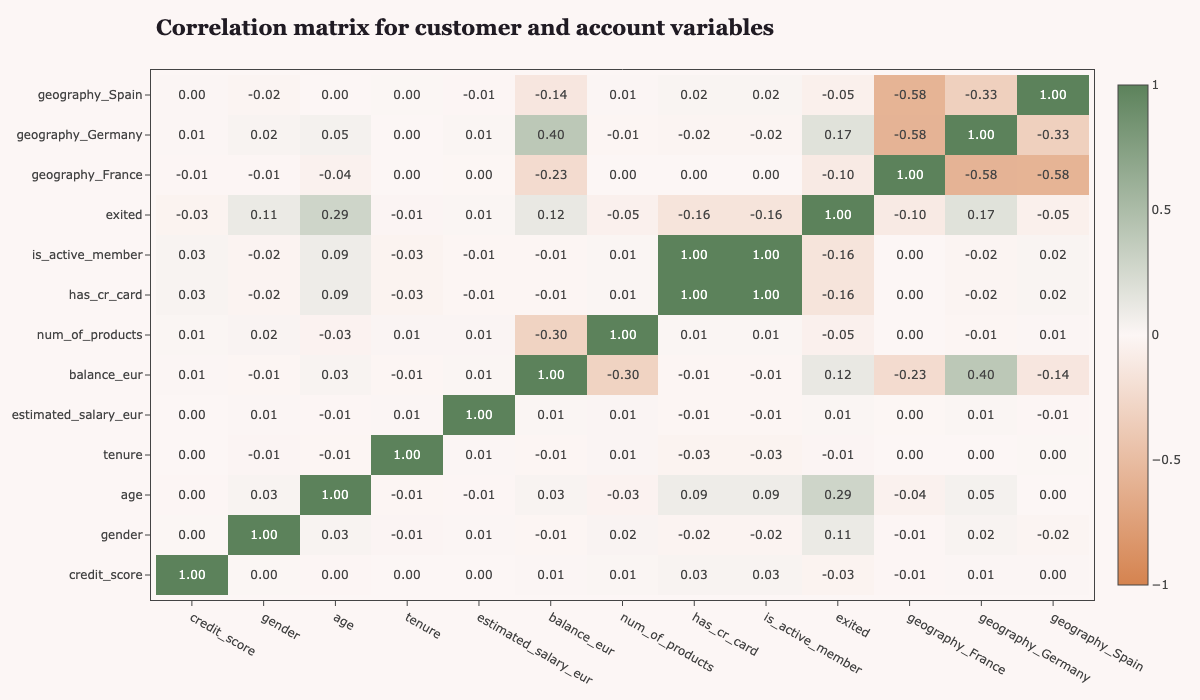

In [18]:
fig = go.Figure()
fig.add_trace(go.Heatmap(x=df_correlation.columns,
                         y=df_correlation.columns,
                         z=df_correlation.rows(),
                         texttemplate='%{z:.2f}',
                         zmin=-1, zmax=1,
                         colorscale=[[0, '#D5834F'], [0.5, '#FCF6F5'], [1, '#5C825B']]))

add_titles(fig,
           title='Correlation matrix for customer and account variables')

fig.update_layout(height=900, width=1000)

if RENDER_AS_PNG:
    display_as_png(fig)
else:
    fig.show()

Focusing on variable pairs involving `exited`, we see that some factors already raised as relevant, such as age and living in Germany, have correlation values considerably different from 0. Other than that, it appears that having a credit card, being an active member, gender and balance also have potential impact.

It's important not to rely too heavily on this metric, as it does not capture non-linear relationships. A more advanced method would rely on Machine Learning models whose feature importance we can extract once it has been trained with most data we have.

Since our target variable is a simple boolean outcome, we can resort to a Random Forest Classifier, and test how the model is performing with a simple accuracy metric. Mind, that if we were dealing with any other output type, accuracy would not be ideal. Random Forests, as we do not have much data, won't take much time to train, and since they don't have many parameters to fine tune, we will make a grid search for the best parameters, rather than trying combinations:

In [19]:
X_COLS = [el for el in df_model.columns if el != 'exited']
Y_COL = 'exited'

parameter_set = {
    'n_estimators': [10, 25, 50, 100, 250, 500],
    'max_depth': [None, 5, 10, 20],
    'class_weight': ['balanced',
                     'balanced_subsample', 
                     # Heavier penalty for "churn" outcome
                     {0: 0.1, 1: 5}]
}

rf = RandomForestClassifier(random_state=89379487)
x_train, x_test, y_train, y_test = train_test_split(df_model[X_COLS], df_model[Y_COL], test_size=0.2, random_state=3904832049)

grid_search = GridSearchCV(estimator=rf,
                           param_grid=parameter_set,
                           scoring='accuracy',
                           cv=5,
                           n_jobs=-1)

grid_search.fit(x_train, y_train)
print('Best parameters:', grid_search.best_params_)

y_pred = grid_search.predict(x_test)
print('Test set accuracy:', accuracy_score(y_pred, y_test))

Best parameters: {'class_weight': 'balanced_subsample', 'max_depth': 20, 'n_estimators': 500}
Test set accuracy: 0.8680659670164917


Before we proceed with the feature importance, let's take a look at the confusion matrix to see where the model is making errors:

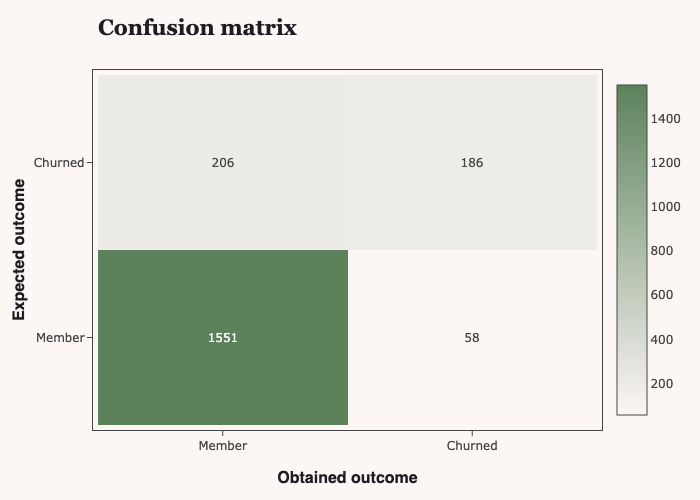

In [20]:
df_confusion_matrix = pl.DataFrame(confusion_matrix(y_test, y_pred), schema=['Member', 'Churned'])

fig = go.Figure()
fig.add_trace(go.Heatmap(x=df_confusion_matrix.columns,
                         y=df_confusion_matrix.columns,
                         z=df_confusion_matrix.rows(),
                         texttemplate='%{z}',
                         zmin=0,
                         colorscale=[[0, '#FCF6F5'], [1, '#5C825B']]))

add_titles(fig,
           title='Confusion matrix',
           x_title='Obtained outcome',
           y_title='Expected outcome')

fig.update_layout(height=500, width=700,
                  yaxis_title_standoff=10)

if RENDER_AS_PNG:
    display_as_png(fig, h=500, w=700)
else:
    fig.show()

There's an unbalance between the amount of current members and churned customers, which makes it so that the test set has a lack of churned rows. The model seems to rely too heavily on guessing a given customer row is a member, which seems to be the "safe" assumption to make. At least the discrepancy between wrong and right "Churned" guesses is not too great, even though it would be ideal to have as many entries in the `Obtained = Expected` diagonal line.

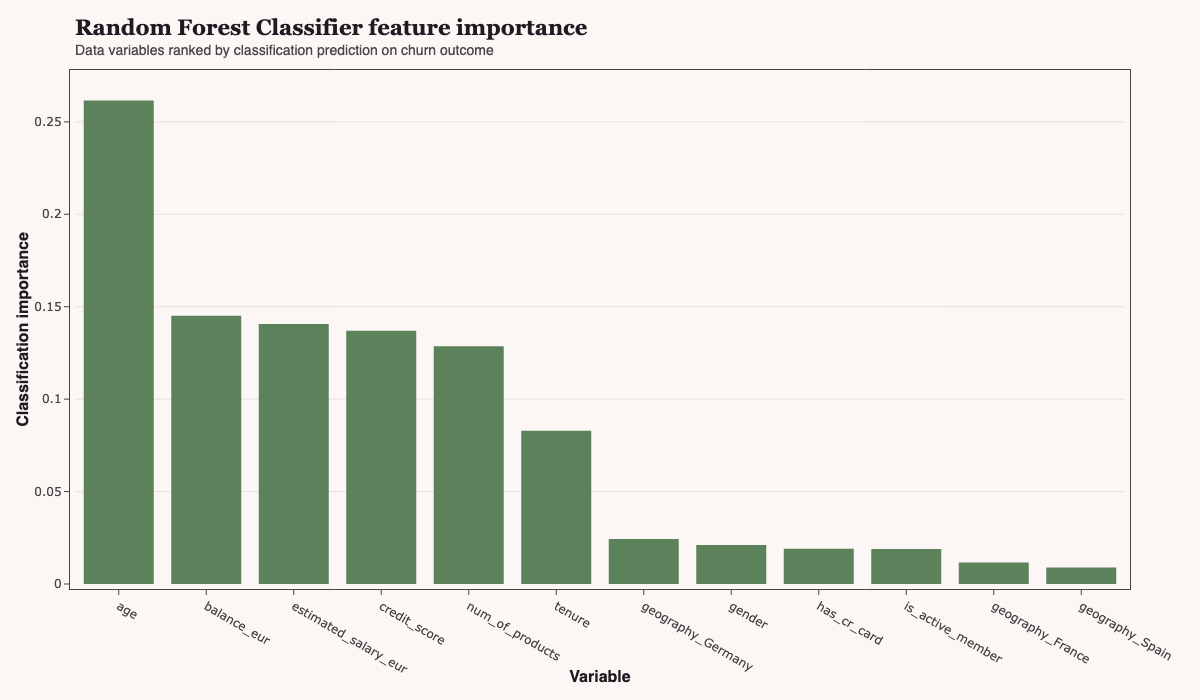

In [21]:
df_features = pl.DataFrame([
    grid_search.best_estimator_.feature_names_in_,
    grid_search.best_estimator_.feature_importances_
], schema=['features', 'importance']).sort('importance', descending=True)

fig = plot_bar(df_features,
               x='features',
               y='importance',
               title='Random Forest Classifier feature importance',
               subtitle='Data variables ranked by classification prediction on churn outcome',
               x_title='Variable',
               y_title='Classification importance',
               return_fig=True)

fig.update_layout(xaxis_title_standoff=0.1)

if RENDER_AS_PNG:
    display_as_png(fig)
else:
    fig.show()

Keep in mind that feature importance works both ways. Since it quantifies how much the model relies on a given variable to make predictions, it will highlight features used to make the right predictions, as well as the wrong ones.

Let's also look at XGBoost Classifier, to see if accuracy improves:

In [22]:
parameter_set = {
    'n_estimators': [50, 100, 250, 350],
    'max_depth': [5, 10, 25],
    'learning_rate': [0.01, 0.05, 0.1]
}

xgbc = xgb.XGBClassifier(random_state=2384923, n_jobs=1, colsample_bytree=0.8)

grid_search_xgb = GridSearchCV(estimator=xgbc,
                               param_grid=parameter_set,
                               scoring='accuracy',
                               cv=5,
                               n_jobs=2)

grid_search_xgb.fit(x_train, y_train)
print('Best parameters:', grid_search_xgb.best_params_)

y_pred = grid_search_xgb.predict(x_test)
print('Test set accuracy:', accuracy_score(y_pred, y_test))

Best parameters: {'learning_rate': 0.05, 'max_depth': 5, 'n_estimators': 250}
Test set accuracy: 0.8655672163918041


Around the same as the Random Forest, nevertheless, let's check if the important features are the same:

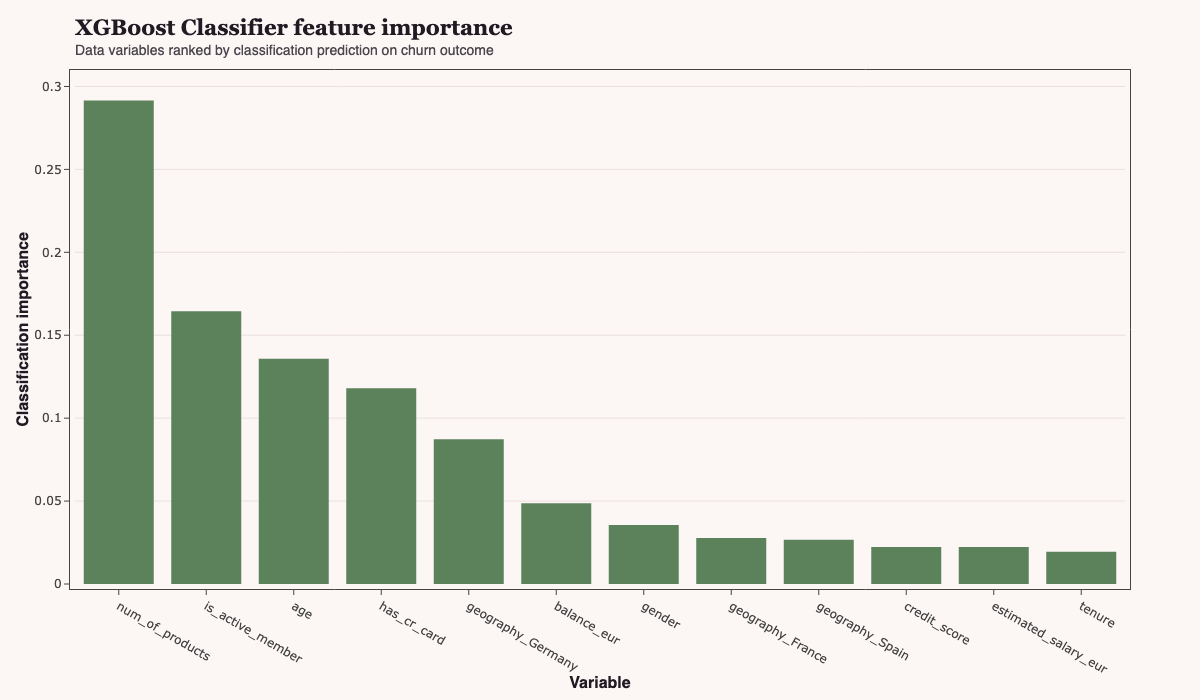

In [23]:
df_features_xgb = pl.DataFrame([
    grid_search_xgb.best_estimator_.feature_names_in_,
    grid_search_xgb.best_estimator_.feature_importances_
], schema=['features', 'importance']).sort('importance', descending=True)

fig = plot_bar(df_features_xgb,
               x='features',
               y='importance',
               title='XGBoost Classifier feature importance',
               subtitle='Data variables ranked by classification prediction on churn outcome',
               x_title='Variable',
               y_title='Classification importance',
               return_fig=True)

fig.update_layout(xaxis_title_standoff=0.1)

if RENDER_AS_PNG:
    display_as_png(fig)
else:
    fig.show()

Some variables were considered more important by both methods, but not all, here is a breakdown:

<div style="display: flex">
    <div style="flex: 1 1 0px">
        <h3>Correlation matrix</h3>
        <ul>
            <li><b>Age;</b></li>
            <li>Country (Germany);</li>
            <li>Credit card;</li>
            <li>Active member;</li>
            <li>Account balance;</li>
            <li>Gender.</li>
        </ul>
    </div>
    <div style="flex: 1 1 0px">
        <h3>Random Forest</h3>
        <ul>
            <li><b>Age;</b></li>
            <li>Account balance;</li>
            <li>Estimated salary;</li>
            <li>Credit score;</li>
            <li>Total products.</li>
        </ul>
    </div>
    <div style="flex: 1 1 0px">
        <h3>XGBoost Classifier</h3>
        <ul>
            <li>Total products;</li>
            <li>Active member;</li>
            <li><b>Age;</b></li>
            <li>Credit card;</li>
            <li>Country (Germany)</li>
        </ul>
    </div>
</div>

All methods highlight age as a possible cause, other common features include total products, country = Germany, account balance and account activity.

## Customer segmentation (clustering)

To avoid repeating the above EDA but broken down by customer geography, we will make use of clustering methods and take a look at which types of clusters arise in the results.

There are a plethora of clustering methods, here are the determining factors that we must keep in mind:
 - relatively low amount of clusters;
 - likely uneven cluster size;
 - some numerical variables operate on much higher ranges than other ones (e.g.: balance vs credit score);
 - high amount of variables (dimensionality reduction may be needed);
 - there are both numerical and categorical variables.

**Note:** regarding the 4th and 5th concern, FAMD was considered as a dimensionality reduction approach but was disregarded. Even after removing high-cardinality columns like Id and surname, a scree plot shows that even with 100 components the cumulative variance % barely reached 20%, showing an almost linear increase. Code for this is not included so as to avoid the extra dependencies this approach would require.

Let's address the 4th concern. We have too many variables to visualize, so let's reduce them. First thing's first, a scree plot will tell us how many components PCA would require to explain the bulk of data:

In [24]:
scaling_cols = ('credit_score', 'age', 'tenure', 'estimated_salary_eur', 'balance_eur', 'num_of_products')

scaler = StandardScaler()
df_dim = pl.DataFrame(scaler.fit_transform(df[scaling_cols].to_numpy()), schema=scaling_cols)

_df_apx = df[['gender', 'has_cr_card', 'is_active_member', 'exited']].with_columns(
    pl.col('gender').replace({'Male': 0, 'Female': 1}).cast(pl.Int64),
    pl.col('has_cr_card').cast(pl.Int64),
    pl.col('is_active_member').cast(pl.Int64),
    pl.col('exited').cast(pl.Int64)
)
_df_apx = _df_apx.hstack(df['geography'].to_dummies())

df_dim = df_dim.hstack(_df_apx)
del _df_apx

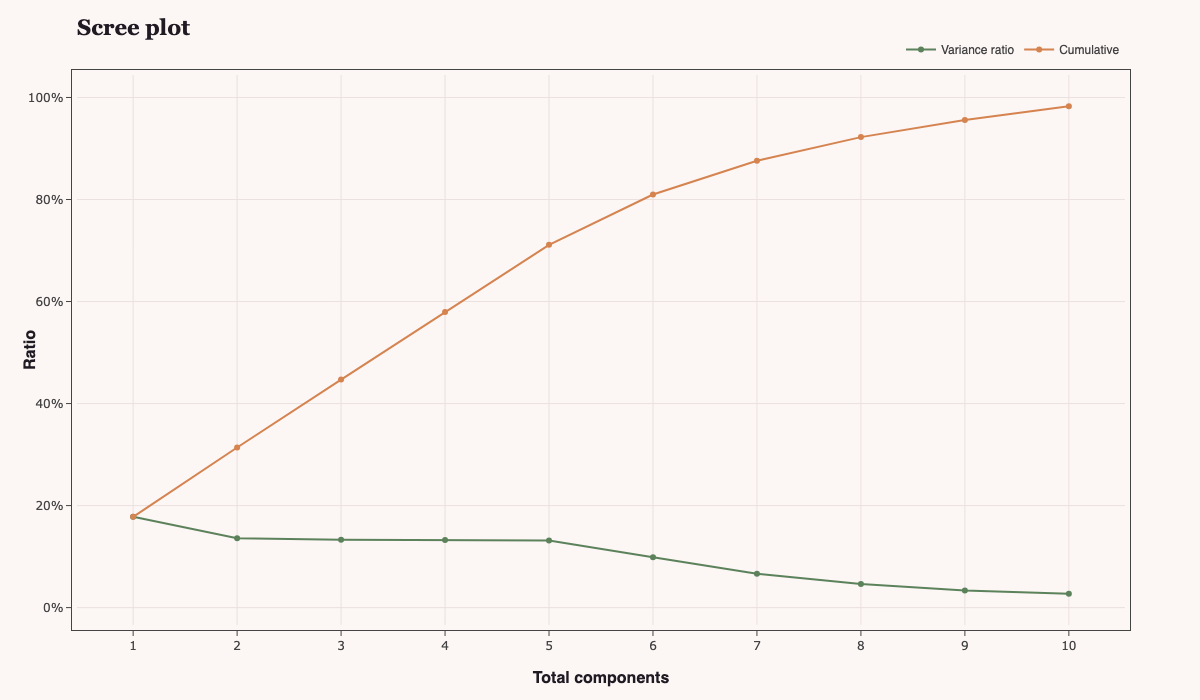

In [25]:
fig = scree_plot(df_dim, 10, return_fig=True)

if RENDER_AS_PNG:
    display_as_png(fig)
else:
    fig.show()

Looks like 8 are more than enough. Now, we want to get a sense of how "clustered" the data is. For this we can rely on [Hopkins statistic](https://en.wikipedia.org/wiki/Hopkins_statistic), which measures cluster tendency in a dataset. Since this method is stochastic (as it involves random samples), we cannot simply run it once, we will run the method multiple times and calculate the average:

In [26]:
n_components = 8
pca = PCA(n_components=n_components)
df_pc = pl.DataFrame(pca.fit_transform(df_dim.to_numpy()), schema=[f'dim_{n}' for n in range(n_components)])

In [27]:
attempts = 10

res = []
for i in range(attempts):
    res.append(hopkins_statistic(df_pc))

np.mean(res)

np.float64(0.6588227656991605)

A value that is closer to 0.5 than 1 indicates the dataset is probably more randomly distributed than entries aggregated in clusters. Let's calculate this for dimension pairs, to see if any 2D subset can be used to cluster:

In [28]:
hs_matrix = np.zeros((n_components, n_components))

for c1 in range(n_components):
    for c2 in range(c1 + 1, n_components):
        res = []
        col_1 = df_pc.columns[c1]
        col_2 = df_pc.columns[c2]
        for i in range(attempts):
            res.append(hopkins_statistic(df_pc[[col_1, col_2]]))
        hs_matrix[c1, c2] = np.mean(res)
        hs_matrix[c2, c1] = np.mean(res)

df_hs = pl.DataFrame(hs_matrix, schema=df_pc.columns)

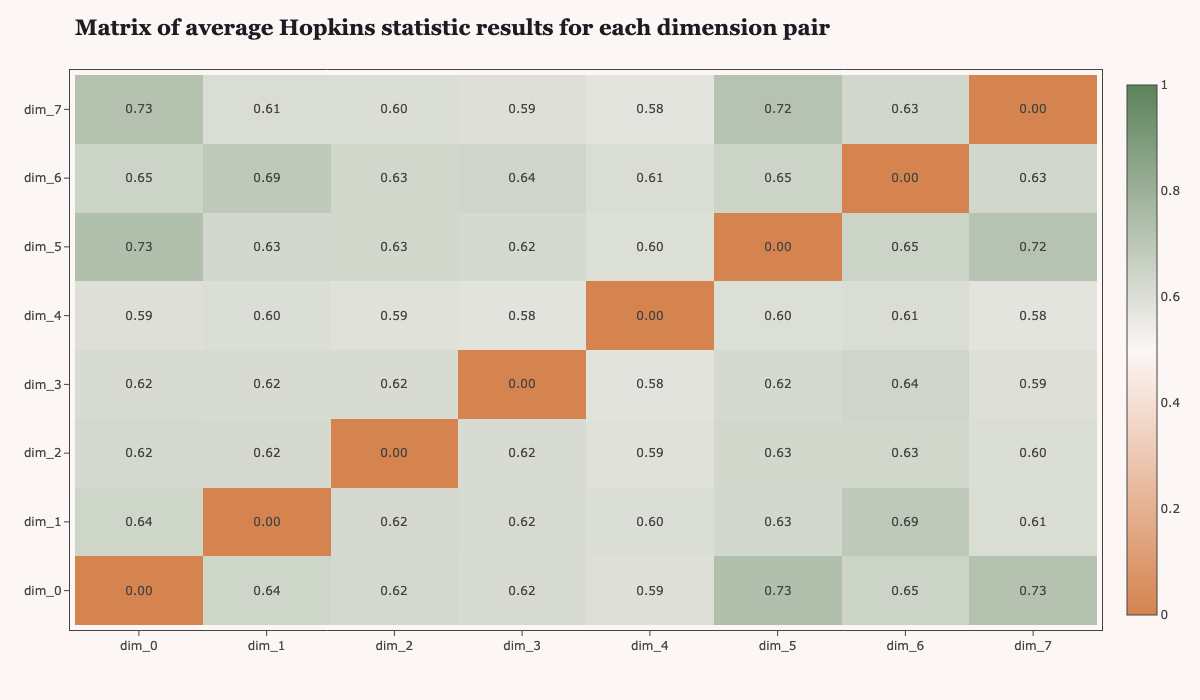

In [29]:
fig = go.Figure()
fig.add_trace(go.Heatmap(x=df_hs.columns,
                         y=df_hs.columns,
                         z=df_hs.rows(),
                         texttemplate='%{z:.2f}',
                         zmin=0, zmax=1,
                         colorscale=[[0, '#D5834F'], [0.5, '#FCF6F5'], [1, '#5C825B']]))

add_titles(fig,
           title='Matrix of average Hopkins statistic results for each dimension pair')

fig.update_layout(height=900, width=1000)

if RENDER_AS_PNG:
    display_as_png(fig)
else:
    fig.show()

Let's check what the dimensions 0 and 5 look like when projected onto 2 dimensions, since this pair maxes out the Hopkins statistic:

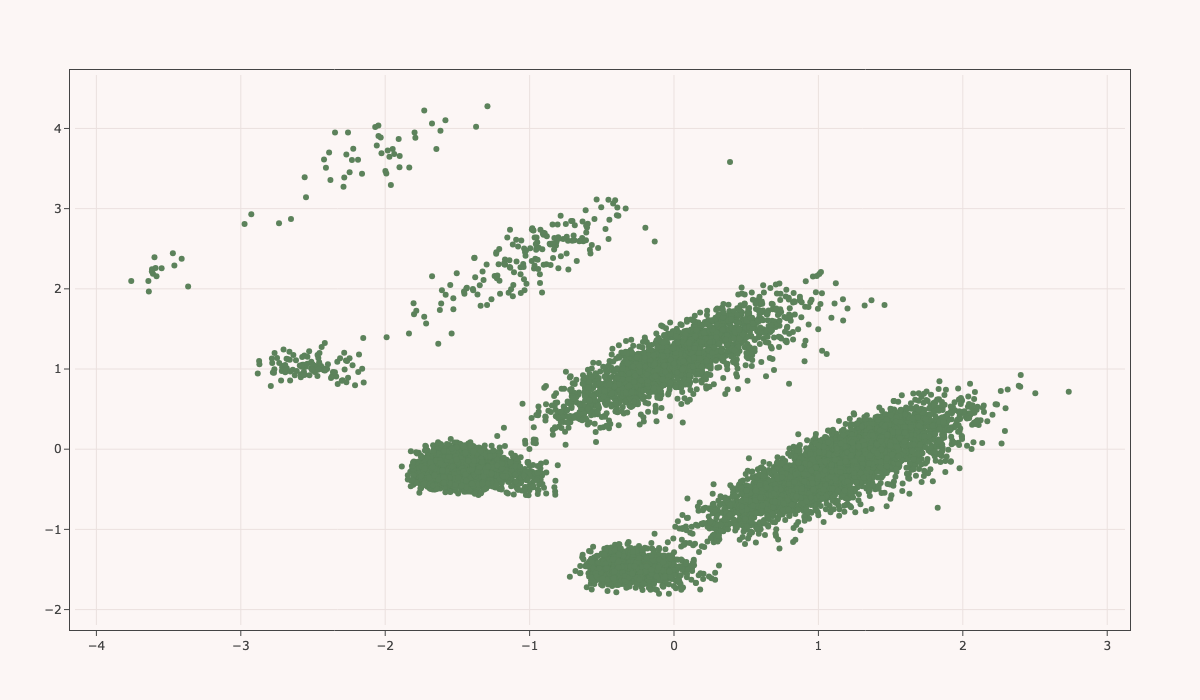

In [30]:
fig = plot_line(df_pc,
                x='dim_0',
                y='dim_5',
                return_fig=True)

fig.update_traces(mode='markers')

if RENDER_AS_PNG:
    display_as_png(fig)
else:
    fig.show()

Indeed, there are some clear clusters, but most of them are not round, so we shouldn't rely on K-means. 

Having said this, should we cluster users based only on this 2 dimensional pair? What variables are relevant for dimensions 0 and 5, really?

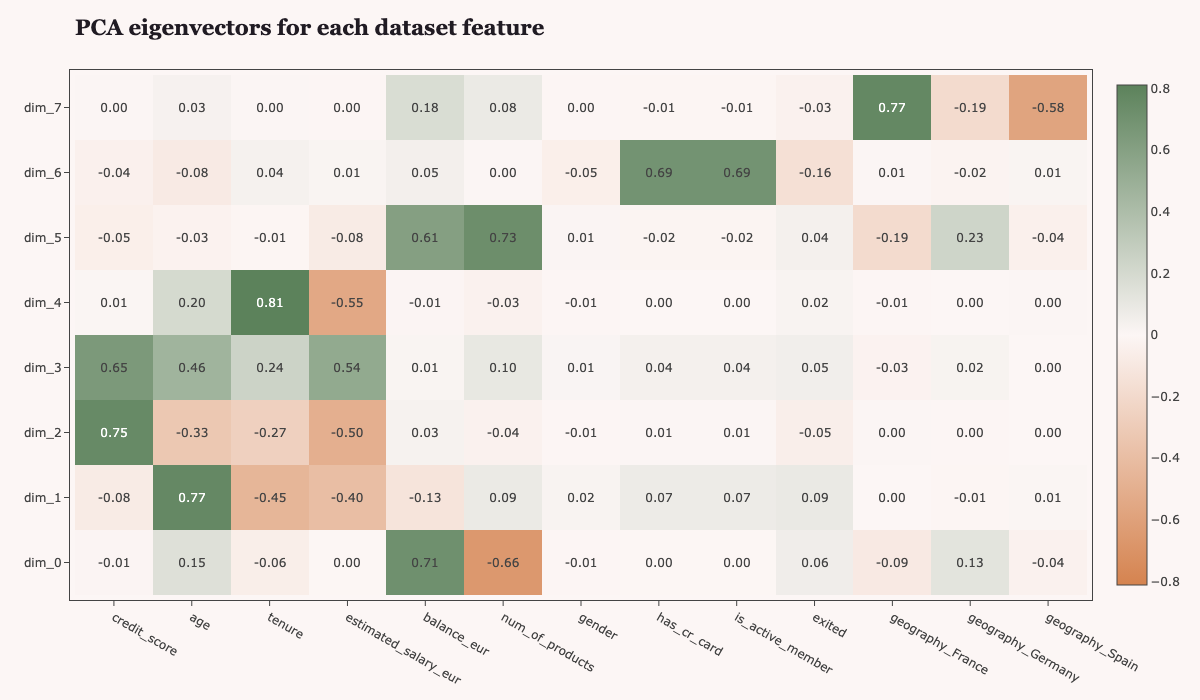

In [31]:
_df = pl.DataFrame(pca.components_, schema=df_dim.columns)

fig = go.Figure()
fig.add_trace(go.Heatmap(x=_df.columns,
                         y=[f'dim_{n}' for n in range(n_components)],
                         z=_df.rows(),
                         texttemplate='%{z:.2f}',
                         zmid=0,
                         colorscale=[[0, '#D5834F'], [0.5, '#FCF6F5'], [1, '#5C825B']]))

add_titles(fig,
           title='PCA eigenvectors for each dataset feature')

fig.update_layout(height=900)

if RENDER_AS_PNG:
    display_as_png(fig)
else:
    fig.show()

Their eigenvectors look pretty similar. If we were to cluster based on dimensions 0 and 5, we would likely get number of products as the main cluster differentiator, and we saw above just how much variance this variable has. So we won't get much from clustering based on dimensions 0 and 5 only.

Let's check the 3D counterpart:

In [32]:
hs_3d = dict()
hs_3d_sets = [frozenset(el) for el in combinations(df_pc.columns, 3)]

for el in hs_3d_sets:
    col_1, col_2, col_3 = el
    
    res = []
    for i in range(attempts):
        res.append(hopkins_statistic(df_pc[[col_1, col_2, col_3]]))

    hs_3d[el] = np.mean(res)

In [33]:
print('Top 3D dimension combinations with highest Hopkins statistic:')
sorted(hs_3d.items(), key=lambda x: x[1], reverse=True)[:5]

Top 3D dimension combinations with highest Hopkins statistic:


[(frozenset({'dim_0', 'dim_5', 'dim_7'}), np.float64(0.8058680785774923)),
 (frozenset({'dim_0', 'dim_5', 'dim_6'}), np.float64(0.7514917822175867)),
 (frozenset({'dim_0', 'dim_1', 'dim_5'}), np.float64(0.7404537902682019)),
 (frozenset({'dim_0', 'dim_3', 'dim_5'}), np.float64(0.7311106491891424)),
 (frozenset({'dim_0', 'dim_6', 'dim_7'}), np.float64(0.7241340082929091))]

Almost all entries include both dimensions 0 and 5. The only exception is the combination of dimensions 0, 6 and 7.

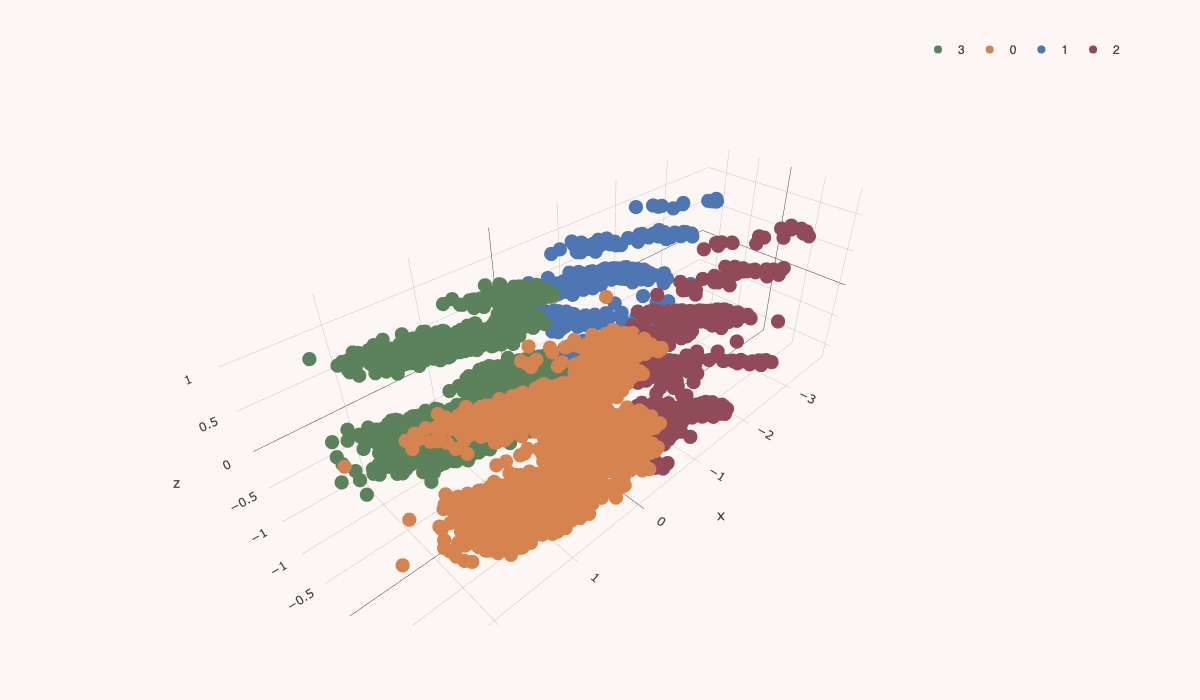

In [34]:
df_spcl = df_pc[['dim_0', 'dim_6', 'dim_7']]
spcl = SpectralClustering(n_clusters=4,
                          assign_labels='discretize').fit(df_spcl.to_numpy())

df_spcl = df_spcl.hstack(pl.DataFrame(spcl.labels_, schema=['cluster']))

fig = go.Figure()

for entry, group in df_spcl.group_by('cluster'):
    fig.add_trace(go.Scatter3d(x=group['dim_0'],
                               y=group['dim_6'],
                               z=group['dim_7'],
                               mode='markers',
                               name=entry[0]))


if RENDER_AS_PNG:
    display_as_png(fig)
else:
    fig.show()

When we took a look at the main diferentiators between these clusters, we found that they differed almost exclusively on the combination of credit card usage and account activity (likely dimension 6), not exactly thrilling results.

Let's forgo the dimension reduction and run the statistic over a clean version of the dataset instead as a last resort:

In [35]:
# When we performed similar matrix calculations as above for Hopkins Statistic, these columns frequently appeared in the top spots
# The exception is account balance, which we introduced as a factor manually
df_spcl = df_dim[['balance_eur', 'has_cr_card', 'is_active_member', 'geography_France', 'geography_Germany', 'geography_Spain', 'exited', 'gender']]

spcl = SpectralClustering(n_clusters=4,
                          assign_labels='discretize').fit(df_spcl.to_numpy())
df_cluster = df.hstack(pl.DataFrame(spcl.labels_, schema=['cluster']))

We get the following:
 - cluster 0: non-active member, Spain or Germany, no credit card
 - cluster 1: France only
 - cluster 2: active member, has credit card
 - cluster 3: non-active member, lower account balances, France and Spain, no credit card

Features that were not mentioned were not differentiators. Cluster 3 highlights how Germany does not register accounts whose balance are on the lower end of the distribution.

## Conclusions

Keeping in mind the recommended analysis by Maven Analytics, we have the following takeaways:
 - Our approaches to establish possible connections between each variable and account outcome (manual visualization, correlation matrix, classification), highlighted different possible attributes to churned accounts, but amongst them, **age was by far the most common potential cause**. Other potential attributes include the country of the client (specifically if it's Germany), as well as account balance, activity and total products.
    - The data has a considerable class inbalance between current members and churned customers. This makes it so that classification based approaches will likely end up with a high amount of false negatives on the smaller class (churn). Some adjustments could be implemented on the preprocessing side, such as removing entries from the current member class, but it could be problematic given the small customer set;
    - XGBoost Classifiers and Random Forest models were tested as machine learning approaches for outcome prediction, but their accuracies were very close (both at around 86%), even though their most relevant features for prediction differed considerably (out of the top 5 "important" features, only 2 were common: age and total products);
 - **Customers in Germany register the highest churn rate**, despite making roughly a quarter of the entire data. On the other hand, Spain, also making up nearly 25% of data, registers the lowest churn rate.
    - Germany is also the country that does not register small balances, an aspect also captured by clustering approaches.